#### Comparing the gene signatures across three fetal stem cells populations and LGR5+/- cells 
- **Developed by:** Anna Maguza
- **Affilation:** Faculty of Medicine, Würzburg University
- **Date of creation:** 10th September 2024
- **Last modified date:** 10th September 2024

This notebook is created to compare three fetal stem cells populations and LGR5+ signatures. Using the list of Lgr5 intestinal stem cell signatures created in Muñoz, 2012 dataset and scoring them to fetal stem cells. The common set of genes was obtained using `ensembl`orthologues.


+ Import packages

In [31]:
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns

+ Load fetal cells

In [17]:
fetal_adata = sc.read_h5ad("data/Fetal_cells_filtered_raw.h5ad")

+ Normalize fetal cells

In [18]:
fetal_adata_log = fetal_adata.copy()
sc.pp.normalize_total(fetal_adata_log, target_sum = 1e6, exclude_highly_expressed = True) #1e6 because it is 10X
sc.pp.log1p(fetal_adata_log)

In [19]:
df = fetal_adata_log.obs['Cell States'].value_counts()

In [20]:
fetal_adata_log = fetal_adata_log[fetal_adata_log.obs['Cell States'].isin(['MTRNR2L12+ASS1+_SC', 'TA', 'RPS10+_RPS17+_SC',
                                                                           'FXYD3+_CKB+_SC', 'Enterocyte'])]

/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


In [21]:
fetal_adata_log_copy = fetal_adata_log.copy()

### Score LGR5+ signatures from Muñoz, 2012 paper

+ Create a common set of genes using `ensembl`orthologues database

In [22]:
orthologues_ensembl = pd.read_csv("database_data/ensembl_data/mouse_to_human_orthologues_ensembl.txt", sep = "\t")

In [23]:
munoz_signatures= pd.read_excel("data/Munoz_2012/embj2012166-sup-0002.xls", sheet_name = "S12")

In [24]:
munoz_signatures = munoz_signatures.iloc[2:]

In [25]:
munoz_signatures = munoz_signatures.rename(columns = {munoz_signatures.columns[1]: 'Description'})

+ Score all genes from Muñoz, 2012 dataset

In [26]:
merged = pd.merge(munoz_signatures['The intestinal stem cell signature'], orthologues_ensembl, left_on='The intestinal stem cell signature', right_on='Gene name', how='left')

In [27]:
munoz_signatures_genes = set(merged['Human gene name'].dropna().unique())

In [28]:
len(munoz_signatures_genes)

454

In [29]:
sc.tl.score_genes(fetal_adata_log, gene_list=munoz_signatures_genes, score_name='lgr5_positive_score')

/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/scanpy/tools/_score_genes.py:175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[score_name] = pd.Series(


/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-

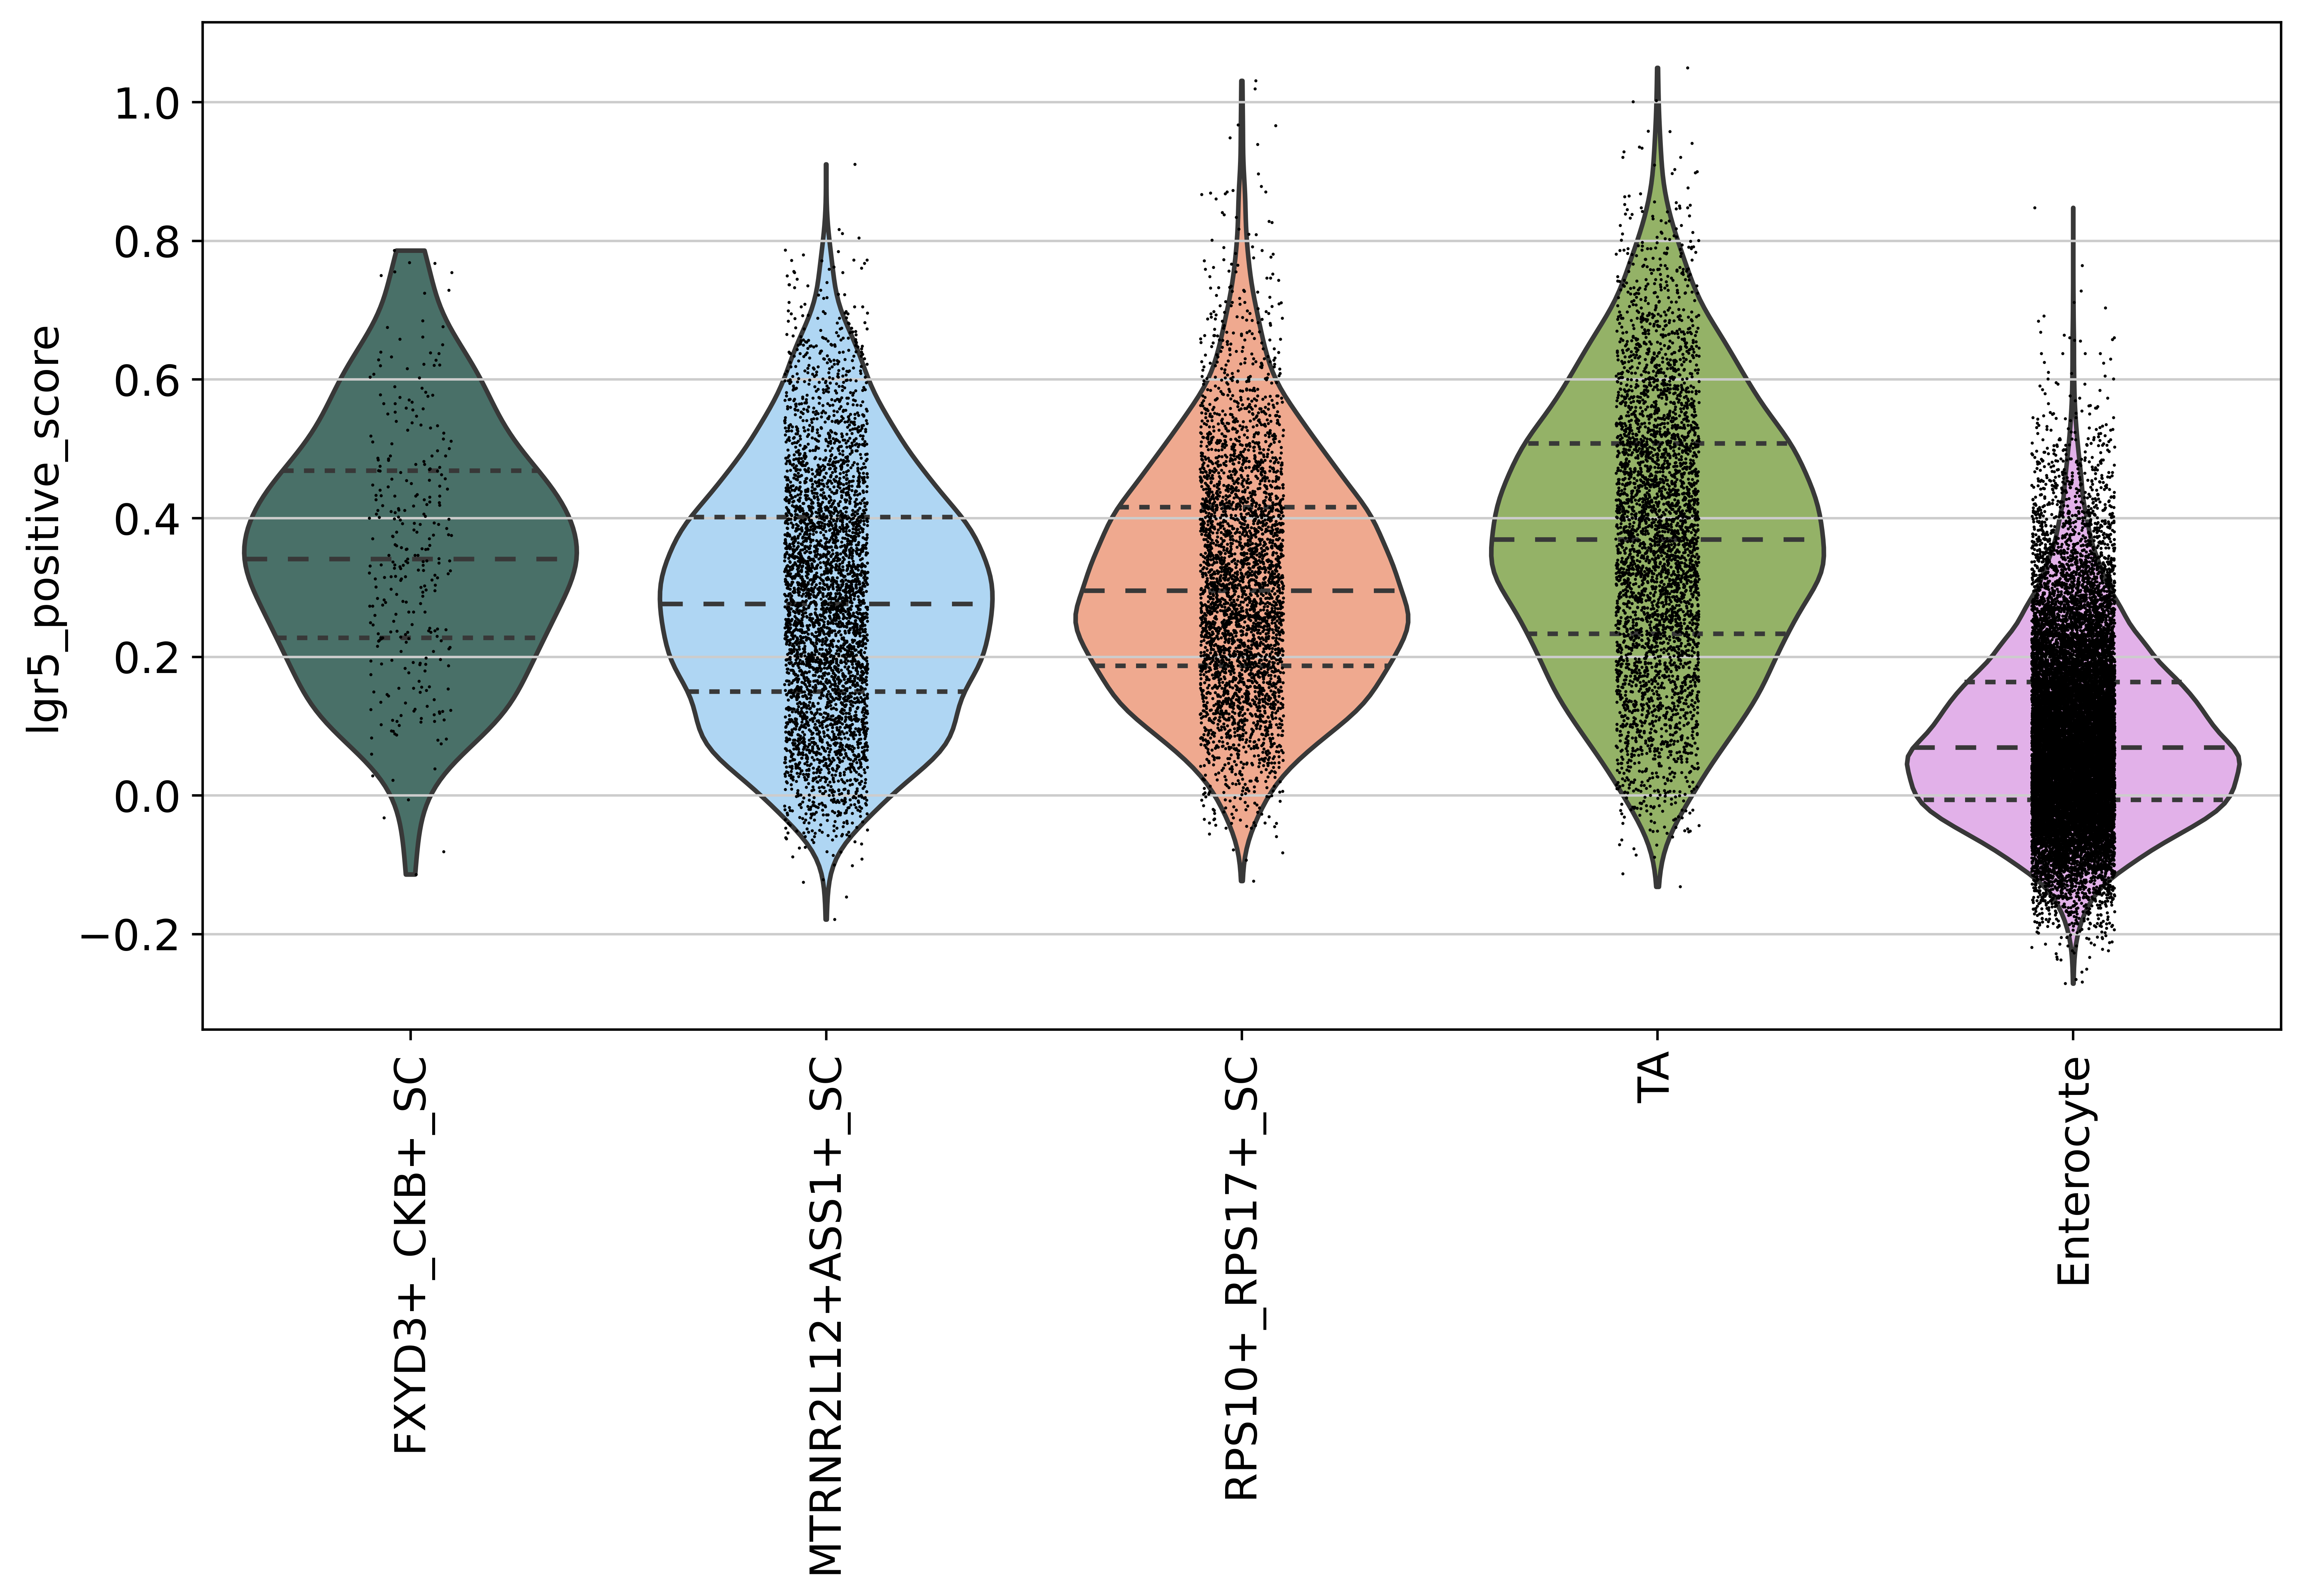

In [39]:
custom_palette = sns.color_palette(['#43766C', '#A3D8FF', '#FFA27F', '#97BE5A', '#E9A8F2', '#94FFD8'])

cell_order = ['FXYD3+_CKB+_SC', 'MTRNR2L12+ASS1+_SC', 'RPS10+_RPS17+_SC', 'TA', 'Enterocyte']

sc.set_figure_params(dpi=300, figsize=(10, 6))
sc.pl.violin(fetal_adata_log, keys='lgr5_positive_score', groupby='Cell States', stripplot=True, inner="quartile",
             palette=custom_palette, order=cell_order, rotation=90)

+ Check if the developmental stage makes a difference

In [57]:
fetal_adata_log.obs['cell_type_age_group'] = fetal_adata_log.obs['Cell States'].astype(str) + '_' + fetal_adata_log.obs['Age_group'].astype(str)

/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:770: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[groupby]):
/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/home/amaguza/miniforge3/envs/scanpy_env/lib/python

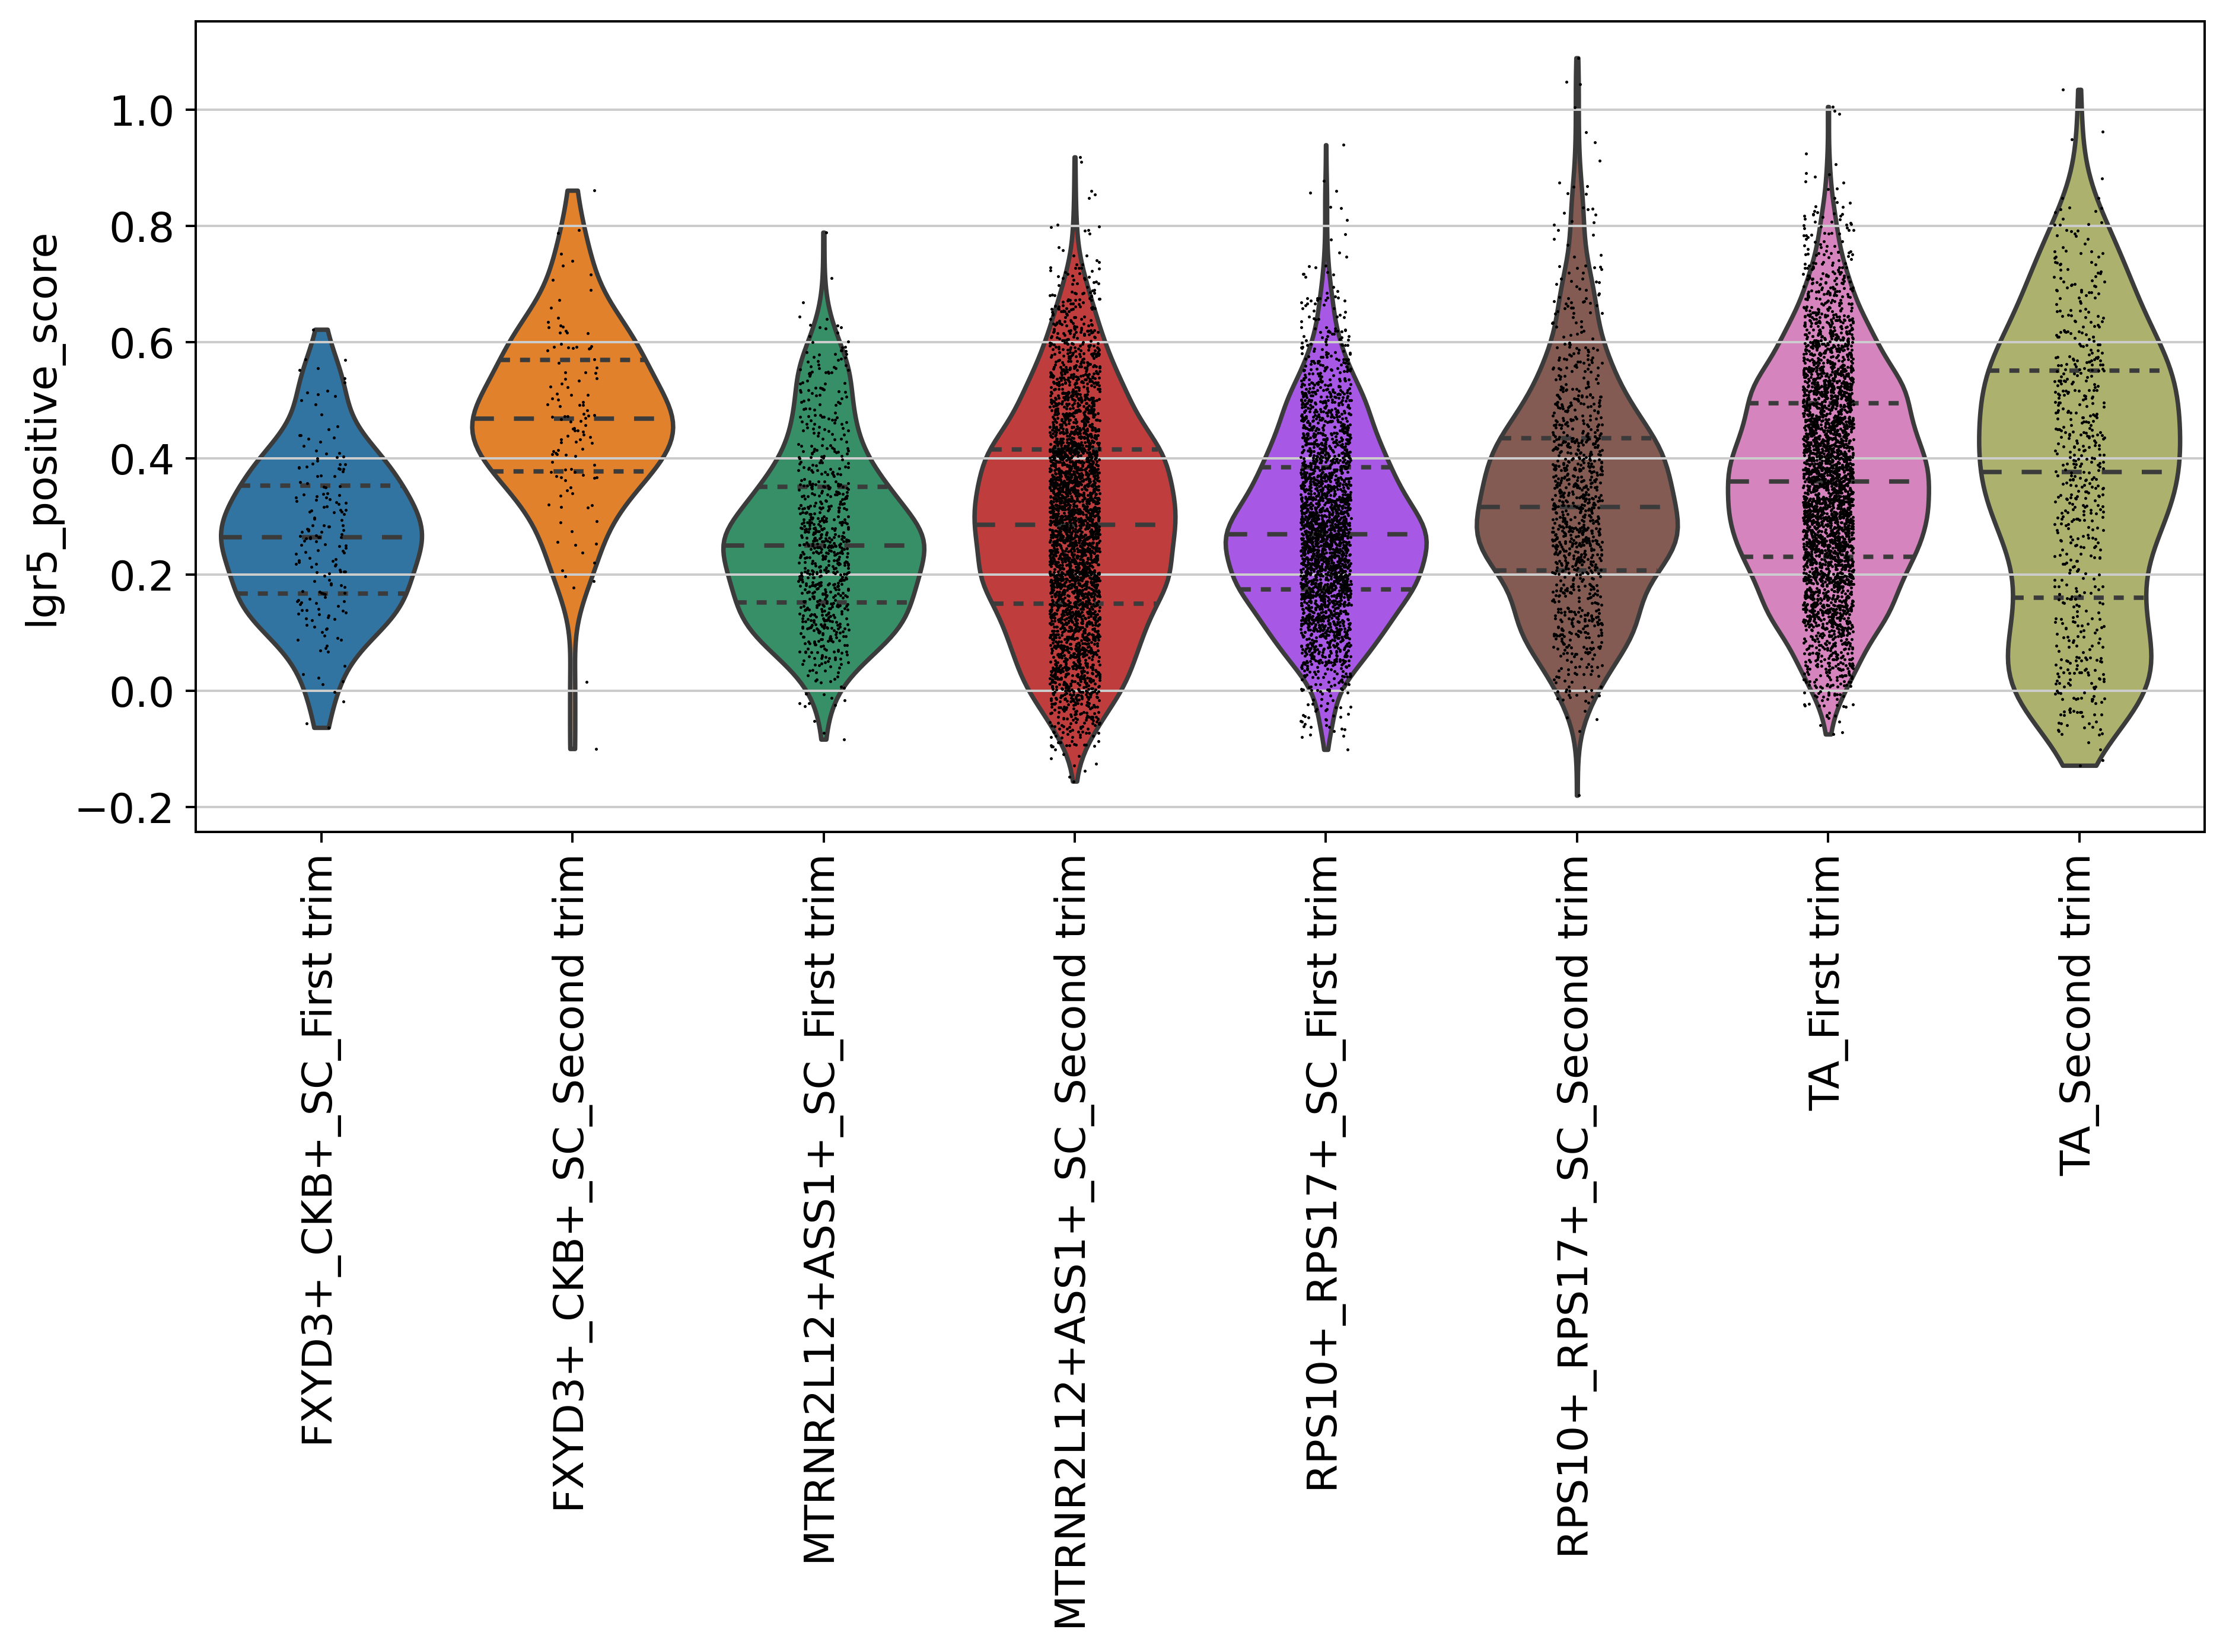

In [58]:
sc.set_figure_params(dpi=180, figsize=(10, 5))
sc.pl.violin(fetal_adata_log, keys='lgr5_positive_score', groupby='cell_type_age_group', stripplot=True, inner="quartile", rotation = 90)

+ Score genes that are enriched in both transcriptomics and proteomics profiles

In [59]:
munoz_signatures['Description'].value_counts()

Description
enriched in Mass Spec, enriched in either Agilent, Affymetrix or both    147
overlap Agilent Affymetrix                                               122
significant in Affy, enriched in Agilent                                 119
significant in Agilent, enriched in Affy                                  50
overlap Agilent Affymetrix MassSpec                                       33
significant in Affy, enriched in Agilent and MassSpec                     28
significant in Agilent, enriched in Affy and MassSpec                      5
significant in Affy, enriched in MassSpec                                  3
significant in Agilent, enriched in MassSpec                               3
Name: count, dtype: int64

In [41]:
munoz_signatures_transcriptomics_and_proteomics = munoz_signatures[munoz_signatures['Description'].str.contains("enriched in Mass Spec, enriched in either Agilent, Affymetrix or both")]

In [42]:
merged = pd.merge(munoz_signatures_transcriptomics_and_proteomics['The intestinal stem cell signature'], orthologues_ensembl, left_on='The intestinal stem cell signature', right_on='Gene name', how='left')

In [43]:
munoz_signatures_genes_transcriptomics_and_proteomics = set(merged['Human gene name'].dropna().unique())

In [63]:
len(munoz_signatures_genes_transcriptomics_and_proteomics)

135

In [64]:
sc.tl.score_genes(fetal_adata_log, gene_list=munoz_signatures_genes_transcriptomics_and_proteomics, score_name='lgr5_positive_score')

/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:770: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[groupby]):
/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/home/amaguza/miniforge3/envs/scanpy_env/lib/python

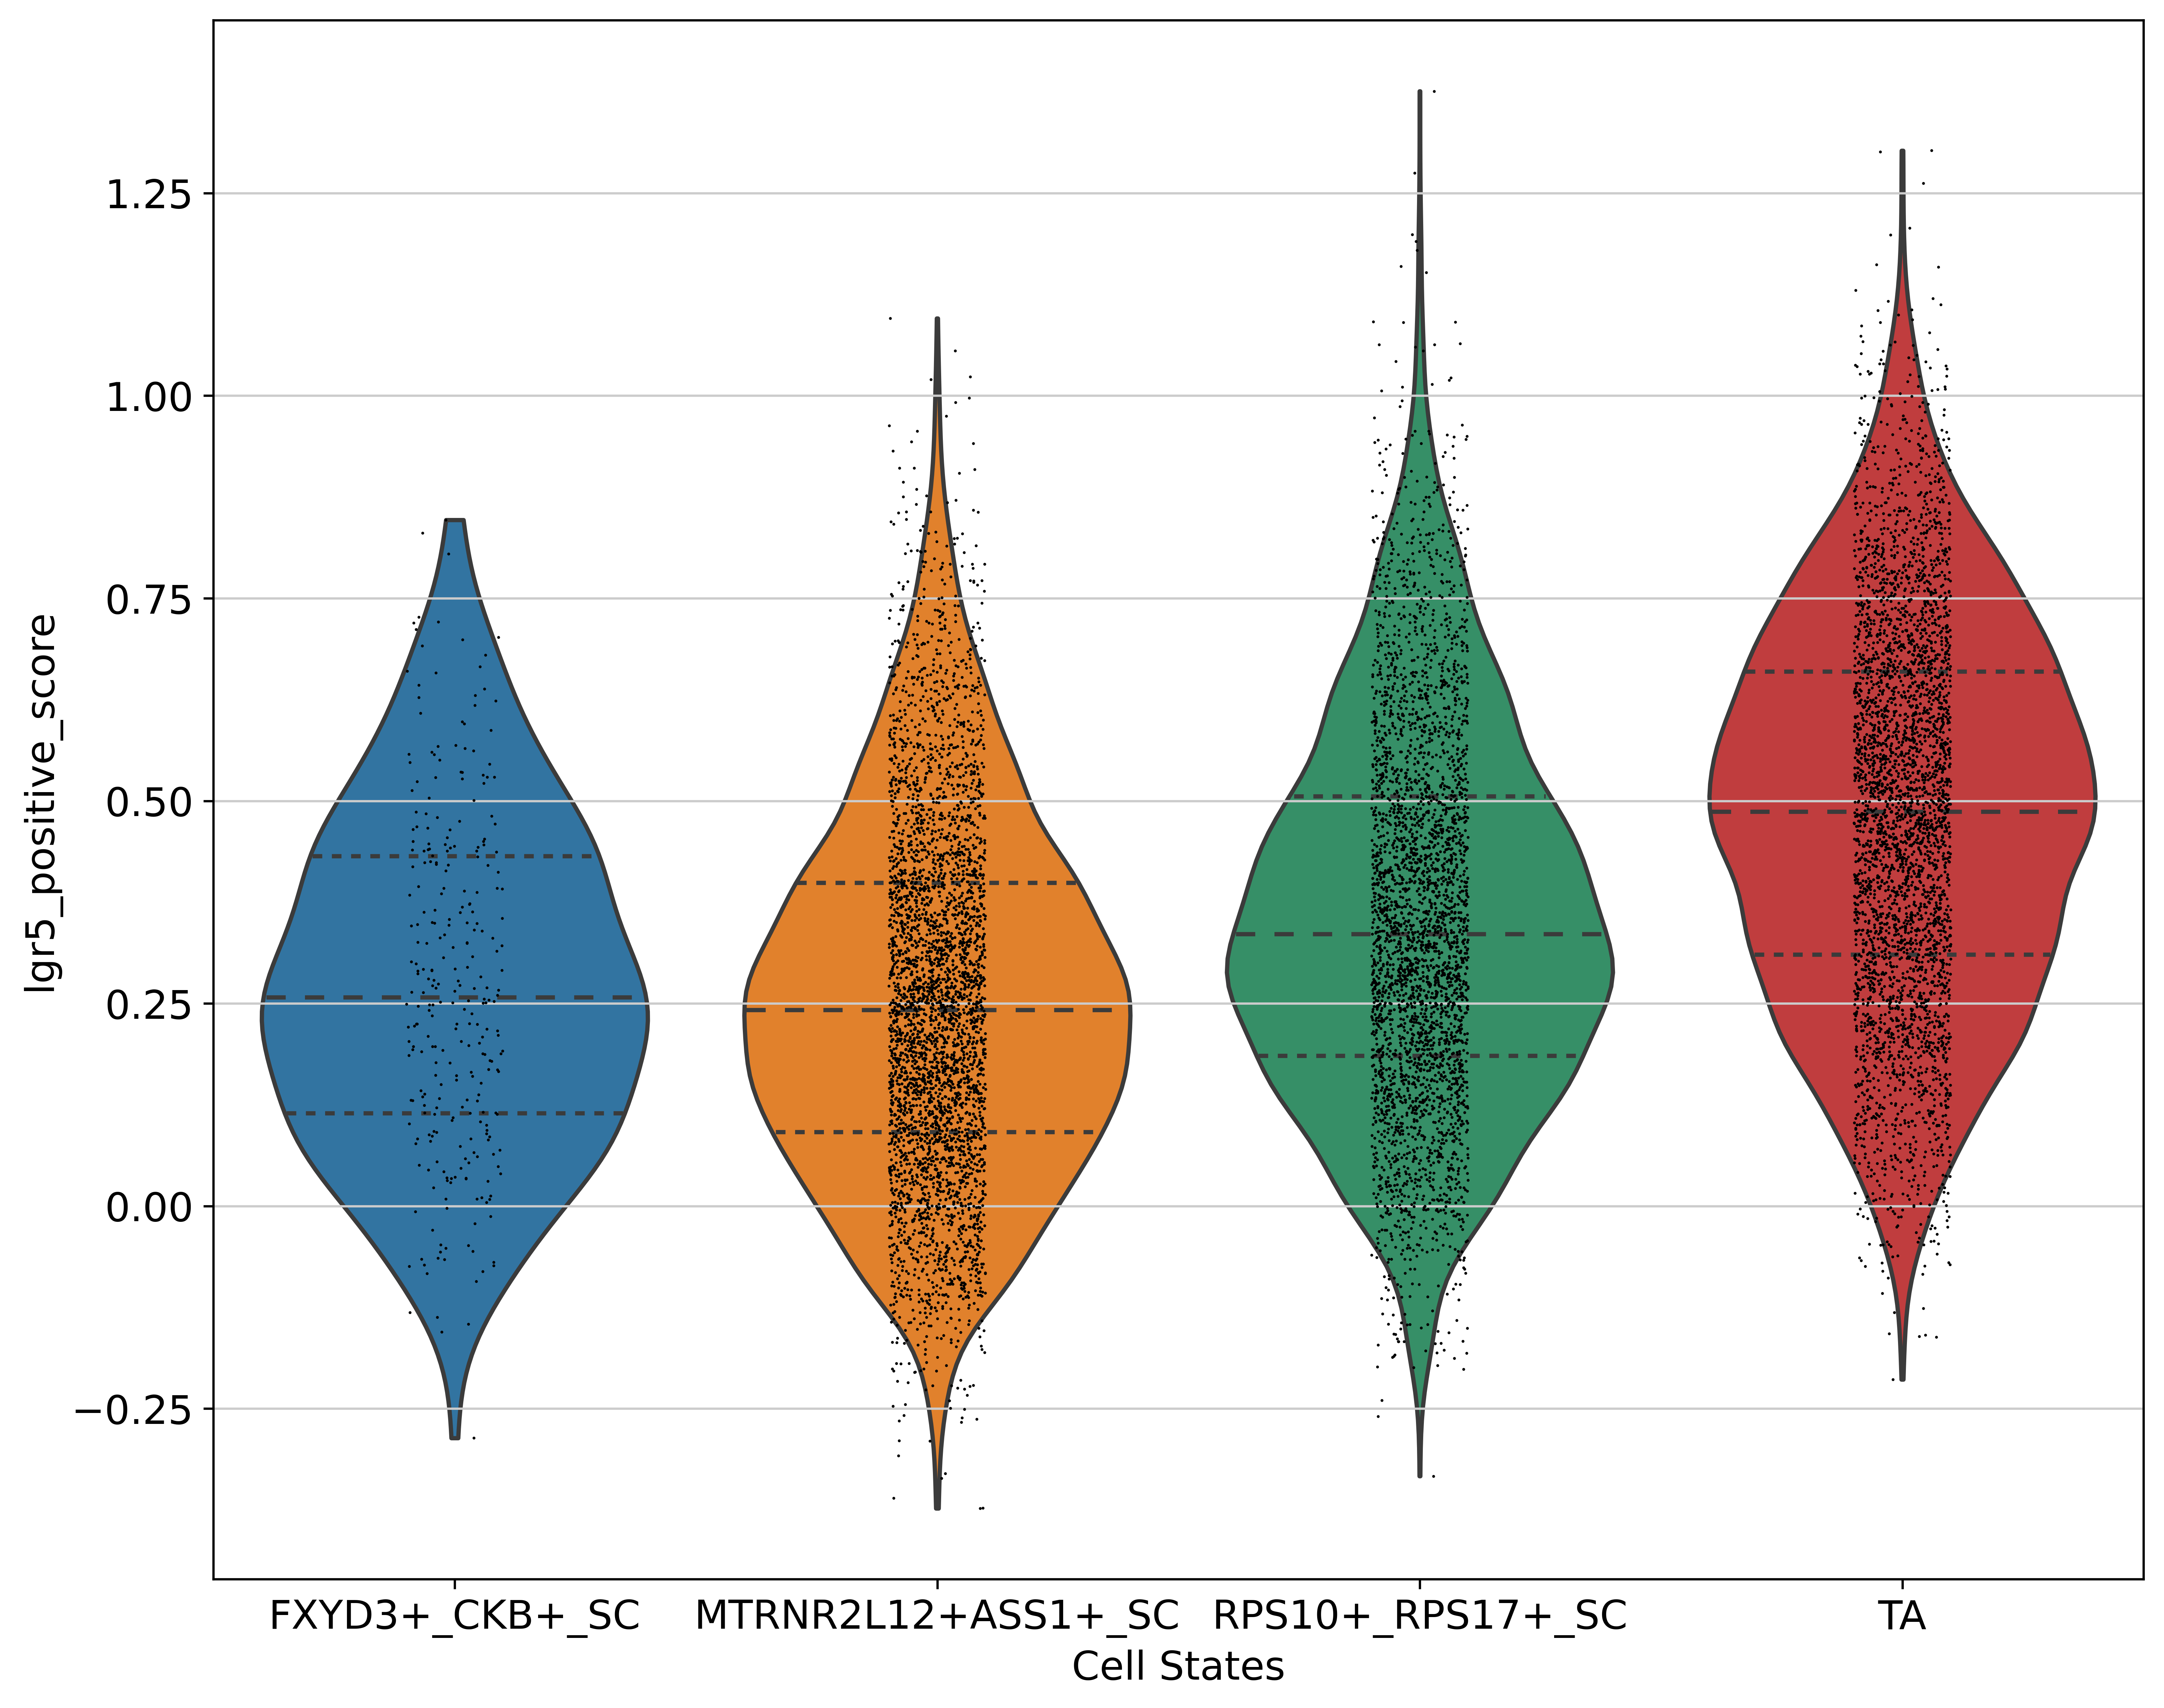

In [65]:
sc.set_figure_params(dpi=300, figsize=(10, 10))
sc.pl.violin(fetal_adata_log, keys='lgr5_positive_score', groupby='Cell States', stripplot=True, inner="quartile")

/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:770: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[groupby]):
/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/home/amaguza/miniforge3/envs/scanpy_env/lib/python

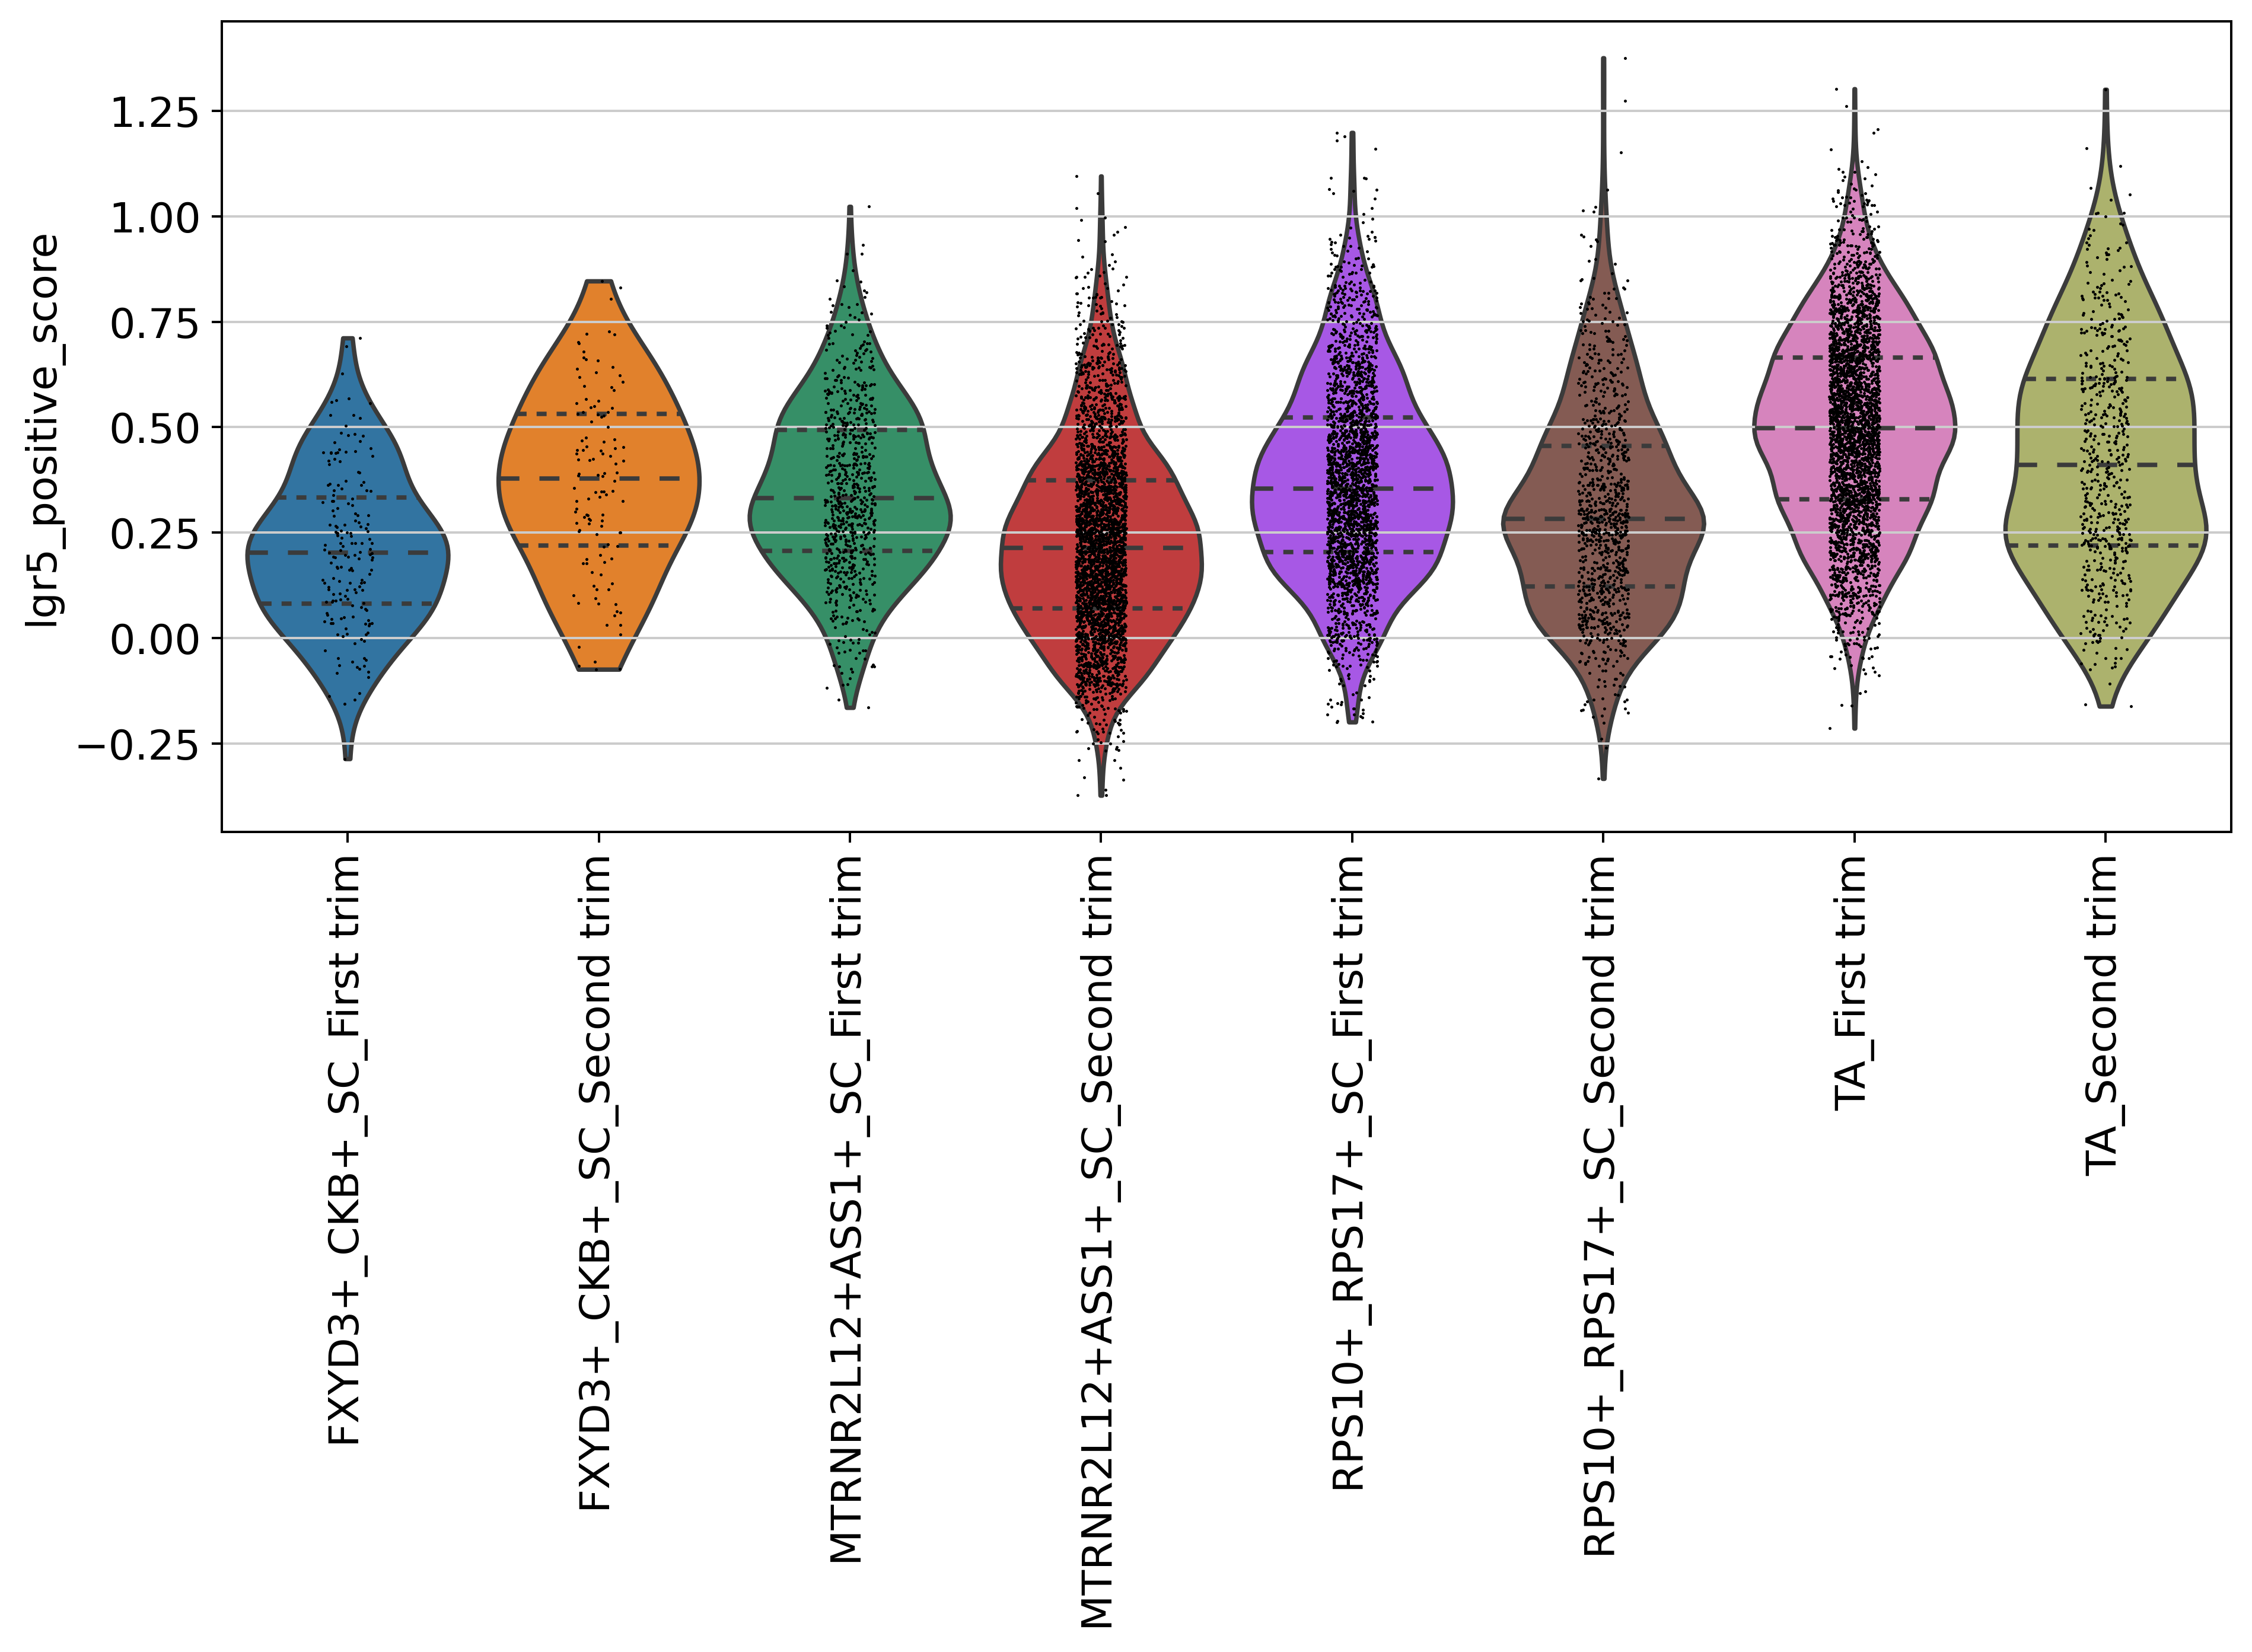

In [66]:
sc.set_figure_params(dpi=180, figsize=(10, 5))
sc.pl.violin(fetal_adata_log, keys='lgr5_positive_score', groupby='cell_type_age_group', stripplot=True, inner="quartile", rotation = 90)

+ Compare with adult cells

In [54]:
adult_adata = sc.read_h5ad("data/Healthy_reference/Integrated/Healthy_integrated_data_all_genes.h5ad")

In [55]:
adult_adata = adult_adata[adult_adata.obs['Diagnosis'].isin(['Healthy adult', 'Adult Ulcerative Colitis Non-inflamed'])]

/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


In [56]:
adult_adata.obs['Cell States'] = adult_adata.obs['Cell States'].cat.add_categories('Stem cells')
adult_adata.obs.loc[adult_adata.obs['Cell States'] == 'Stem cells OLFM4', 'Cell States'] = 'Stem cells'
adult_adata.obs.loc[adult_adata.obs['Cell States'] == 'Stem cells OLFM4 LGR5', 'Cell States'] = 'Stem cells'
adult_adata.obs.loc[adult_adata.obs['Cell States'] == 'Stem_Cells_GCA', 'Cell States'] = 'Stem cells'
adult_adata.obs.loc[adult_adata.obs['Cell States'] == 'Stem cells OLFM4 PCNA', 'Cell States'] = 'Stem cells'
adult_adata.obs.loc[adult_adata.obs['Cell States'] == 'Stem cells OLFM4 GSTA1', 'Cell States'] = 'Stem cells'
adult_adata.obs.loc[adult_adata.obs['Cell States'] == 'Stem_Cells_ext', 'Cell States'] = 'Stem cells'

/tmp/ipykernel_1519241/1587495805.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adult_adata.obs['Cell States'] = adult_adata.obs['Cell States'].cat.add_categories('Stem cells')


In [57]:
adult_adata = adult_adata[adult_adata.obs['Cell States'].isin(['TA', 'Stem cells'])]

/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


In [58]:
sc.pp.normalize_total(adult_adata, target_sum = 1e6, exclude_highly_expressed = True) #1e6 because it is 10X
sc.pp.log1p(adult_adata)

/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:169: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [64]:
munoz_signatures2 = munoz_signatures[munoz_signatures['Description'].str.contains("overlap Agilent Affymetrix")]
merged = pd.merge(munoz_signatures2['The intestinal stem cell signature'], orthologues_ensembl, left_on='The intestinal stem cell signature', right_on='Gene name', how='left')
munoz_signatures2 = set(merged['Human gene name'].dropna().unique())

In [75]:
sc.tl.score_genes(adult_adata, gene_list=munoz_signatures2, score_name='lgr5_positive_score')

/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:770: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(adata.obs[groupby]):
/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)
/home/amaguza/miniforge3/envs/scanpy_env/lib/python

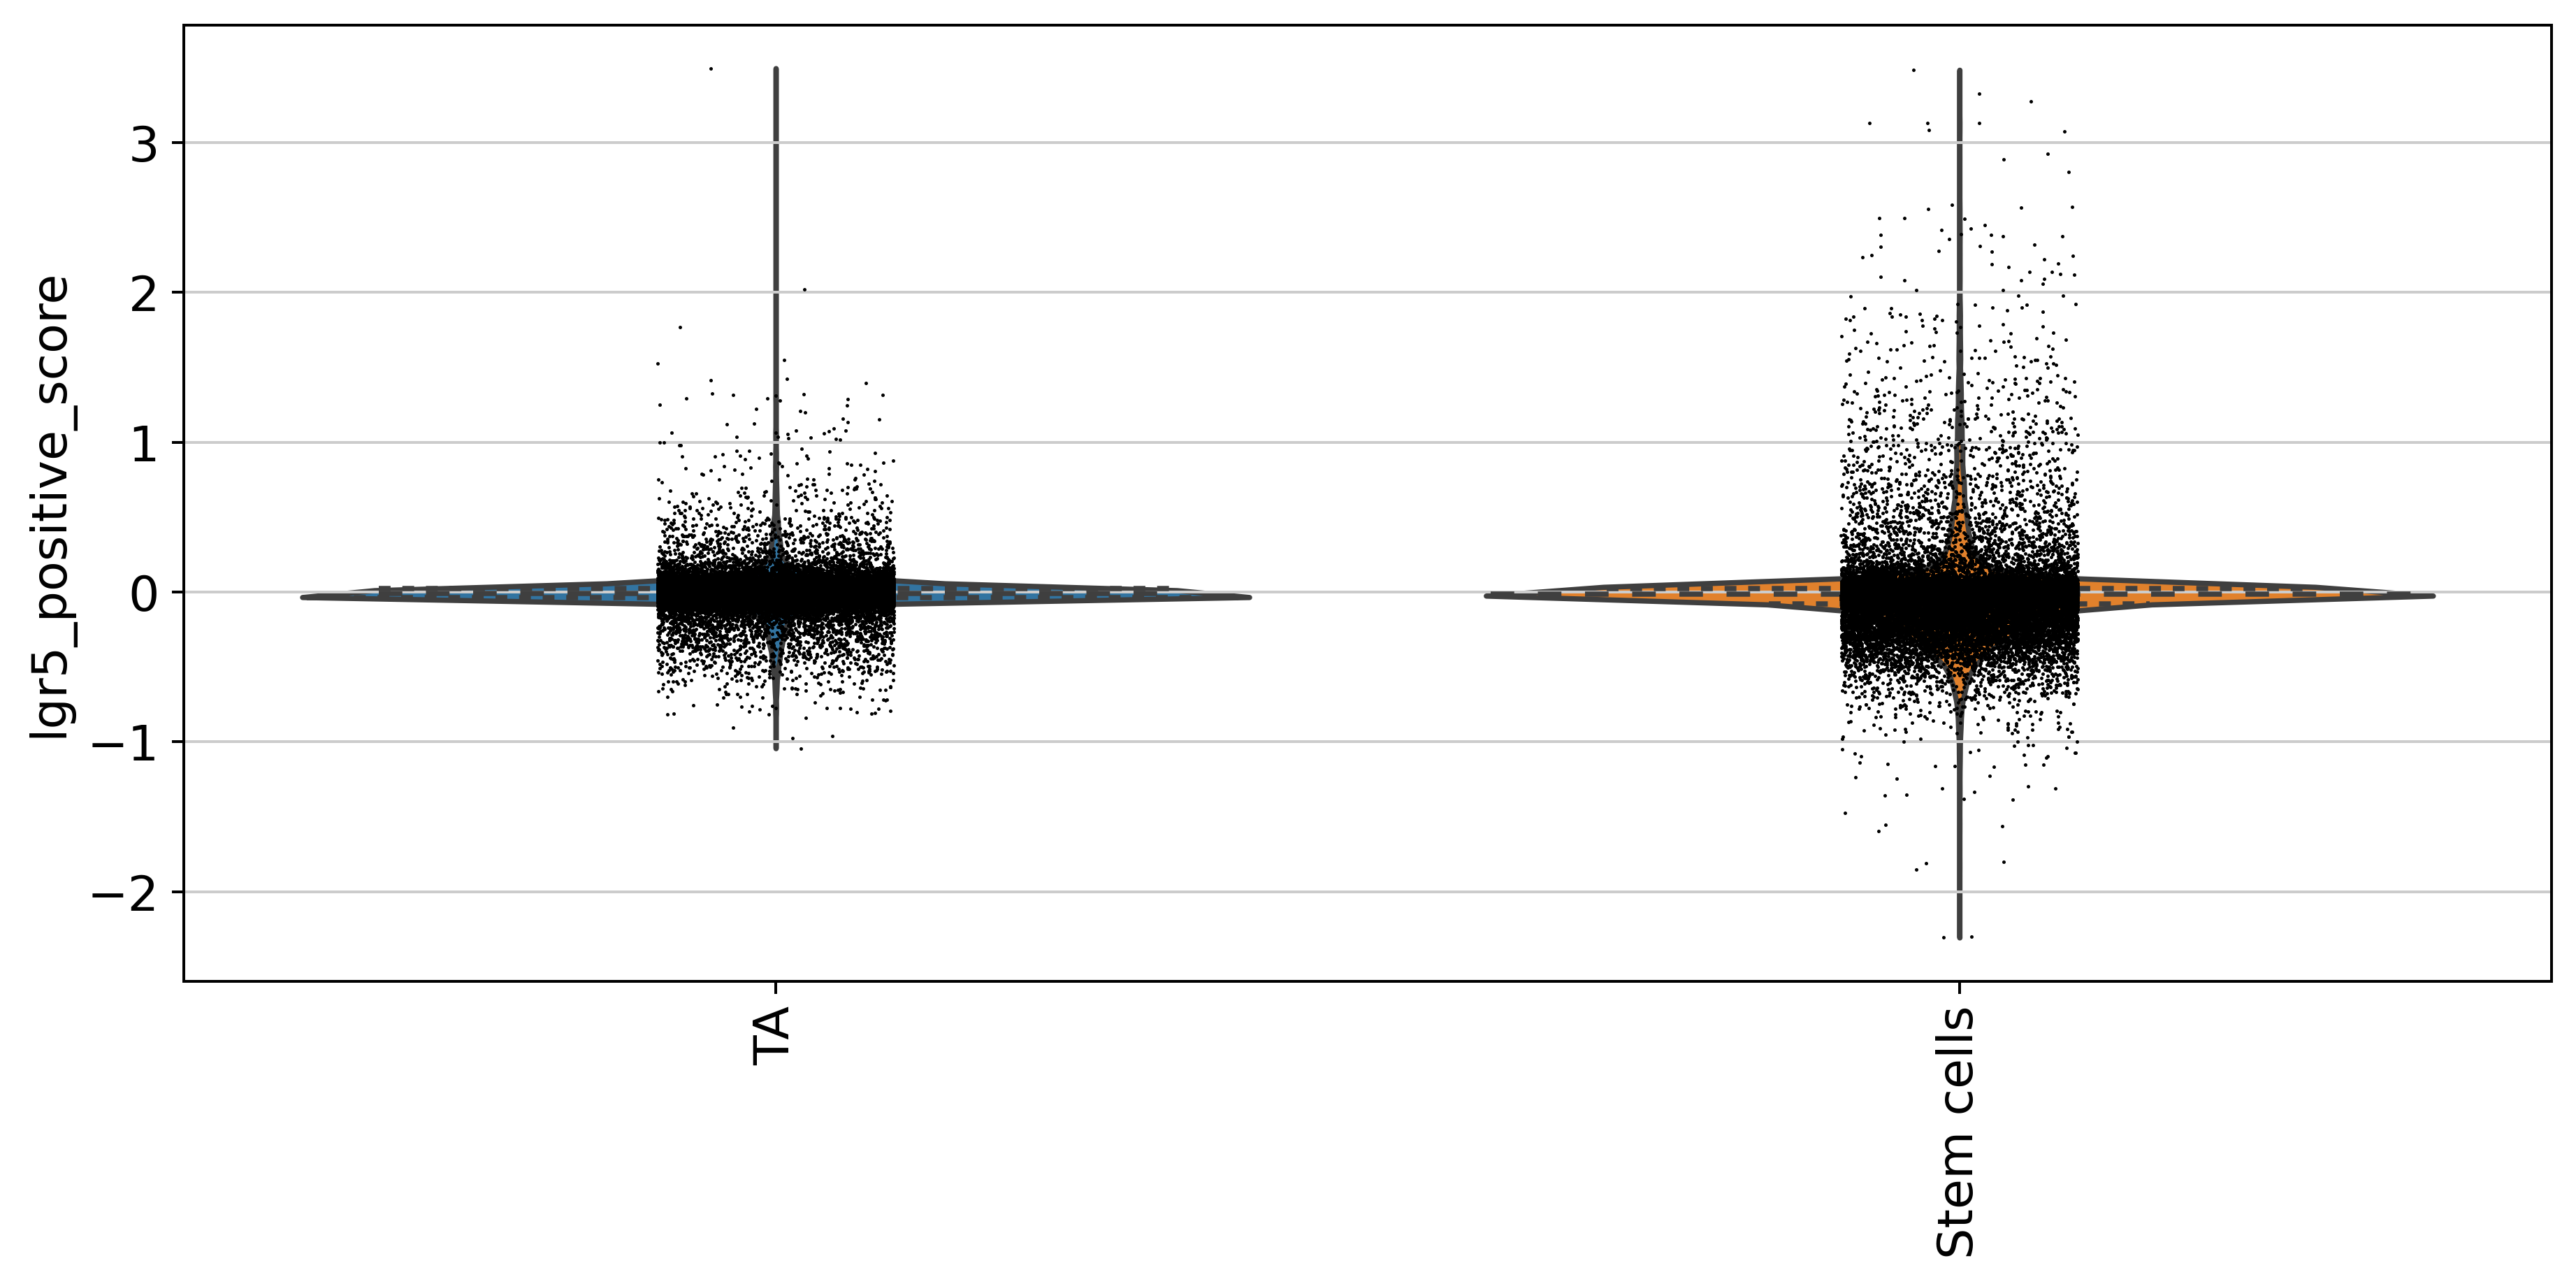

In [76]:
sc.set_figure_params(dpi=180, figsize=(10, 5))
sc.pl.violin(adult_adata, keys='lgr5_positive_score', groupby='Cell States', stripplot=True, inner="quartile", rotation = 90)

+ Visualize the score on the UMAP

In [49]:
fetalSC = sc.read_h5ad('data/Fetal_stem_cells_leiden.h5ad')

In [50]:
sc.pp.normalize_total(fetalSC, target_sum = 1e6, exclude_highly_expressed = True) #1e6 because it is 10X
sc.pp.log1p(fetalSC)

In [51]:
sc.tl.score_genes(fetalSC, gene_list=munoz_signatures_genes, score_name='Lgr5_score')

/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):
/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/anndata/_core/anndata.py:1113: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(df_full[k]):


/home/amaguza/miniforge3/envs/scanpy_env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1207: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if not is_categorical_dtype(values):


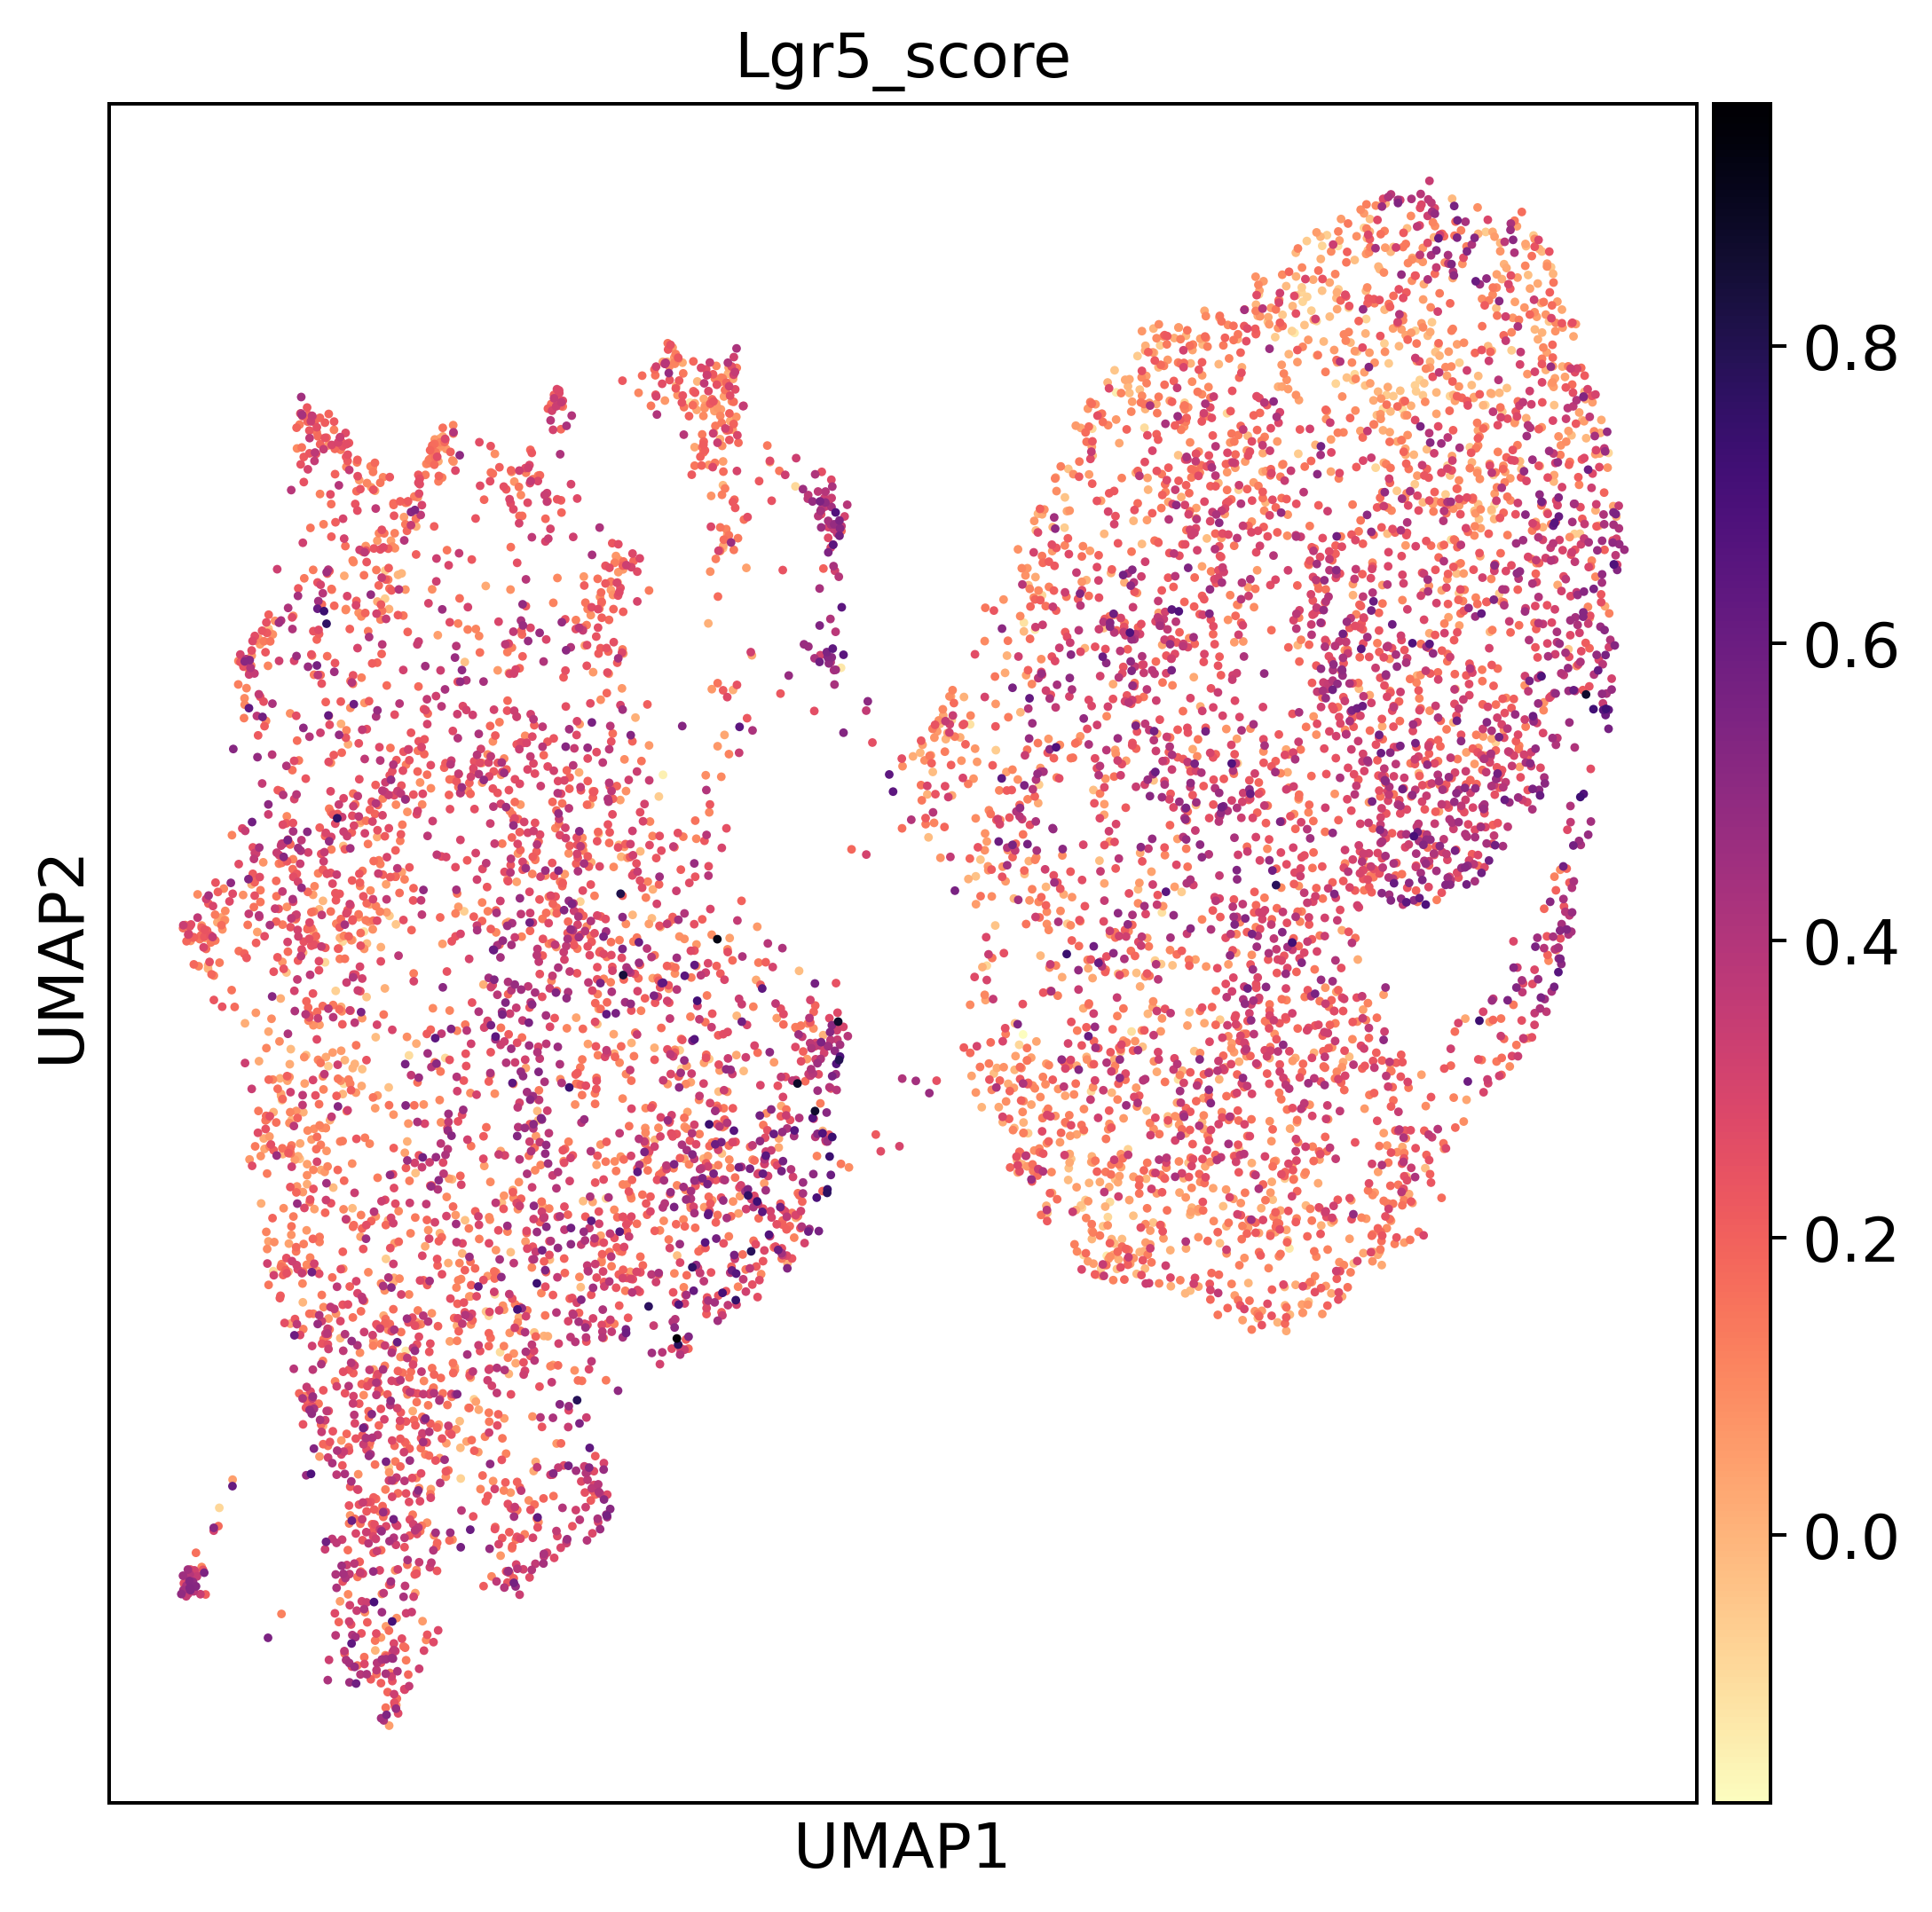

In [52]:
sc.set_figure_params(dpi=180, figsize=(7,7))
sc.pl.umap(fetalSC, color=['Lgr5_score'], color_map = 'magma_r', frameon = False)